In [100]:
from qdrant_client import QdrantClient, AsyncQdrantClient
from llama_index.core import SimpleDirectoryReader, VectorStoreIndex, StorageContext, Settings, Document
from llama_index.embeddings.huggingface import HuggingFaceEmbedding
from llama_index.embeddings.text_embeddings_inference import TextEmbeddingsInference
from llama_index.vector_stores.qdrant import QdrantVectorStore
from llama_index.core.node_parser import SentenceSplitter, TokenTextSplitter
from pathlib import Path
import numpy as np
import torch
import gc
import re
import pandas as pd
from typing import Dict, List, Any
import asyncio


def calculate_metrics(
    retrieved_nodes: List[Any],
    relevant_pages: List[str] | set,
    k: int = 5
) -> Dict[str, float]:
    """
    Подсчёт метрик качества поиска для ОДНОГО запроса.
    
    Входные параметры:
    - retrieved_nodes (List[Any]): список объектов Node, которые вернул retriever
                                   (обычно из index.as_retriever().retrieve(query))
                                   Каждый node должен иметь node.metadata["pages_covered"] — список строк с номерами страниц.
    - relevant_pages (List[str] | set): релевантные страницы для этого запроса.
                                        Пример: ["12", "13"] или {"12", "13"}
    - k (int, по умолчанию 5): сколько топ-чанкок учитывать при расчёте метрик (@k)
    
    Выходные параметры:
    - Dict[str, float] со следующими ключами (все значения округлены до 4 знаков):
        {
            "precision@k": float,     # доля релевантных чанков в топ-k
            "recall@k": float,        # доля релевантных страниц, которые мы достали
            "f1@k": float,            # гармоническое среднее precision и recall
            "hit_rate@k": float,      # GRADED: среднее количество релевантных страниц на один чанк в топ-k
            "ndcg@k": float           # GRADED: нормализованный дисконтированный кумулятивный gain
        }
    """
    relevant_pages = set(relevant_pages)
    
    retrieved_pages = set()           # все страницы, которые мы достали
    relevant_chunks_count = 0         # сколько чанков хотя бы немного релевантны (для precision)
    rel_scores = []                   # GRADED relevance: сколько релевантных страниц в чанке
    
    for node in retrieved_nodes[:k]:
        chunk_pages = set(node.metadata.get("pages_covered", []))
        # print(chunk_pages)
        overlap = len(chunk_pages & relevant_pages)          # ← вот здесь graded
        
        rel_scores.append(overlap)                           # 0, 1, 2, 3...
        retrieved_pages.update(chunk_pages)
        
        if overlap > 0:
            relevant_chunks_count += 1
    
    # === Метрики, которые остались бинарными по "релевантный чанк / нет" ===
    precision = relevant_chunks_count / k if k > 0 else 0.0
    recall = len(retrieved_pages & relevant_pages) / len(relevant_pages) if relevant_pages else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    
    # === hit_rate теперь GRADED ===
    # среднее количество релевантных страниц на один чанк в топ-K
    hit_rate = sum(rel_scores) / k if k > 0 else 0.0
    
    # === nDCG теперь GRADED ===
    dcg = sum(rel / (i + 1) ** 0.5 for i, rel in enumerate(rel_scores))
    ideal_scores = sorted(rel_scores, reverse=True)
    idcg = sum(rel / (i + 1) ** 0.5 for i, rel in enumerate(ideal_scores))
    ndcg = dcg / idcg if idcg > 0 else 0.0
    
    return {
        "precision@k": round(precision, 4),
        "recall@k": round(recall, 4),
        "f1@k": round(f1, 4),
        "hit_rate@k": round(hit_rate, 4),      # теперь graded!
        "ndcg@k": round(ndcg, 4),              # теперь graded!
    }


# def evaluate_collection(
#     index,
#     eval_data: List[Dict],
#     top_k: int = 5,
#     retrieval_k: int = 10
# ) -> pd.DataFrame:
#     """
#     Полная оценка ОДНОЙ коллекции (одного chunk_size) по всему набору тестовых запросов.
    
#     Входные параметры:
#     - index: готовый VectorStoreIndex из LlamaIndex (созданный для текущей коллекции)
#     - eval_data (List[Dict]): список словарей с тестовыми данными.
#                               Каждый элемент должен иметь ровно два ключа:
#                               {
#                                   "query": str,                    # текст вопроса
#                                   "relevant_pages": List[str] | set  # релевантные страницы (как в calculate_metrics)
#                               }
#                               Пример: [{"query": "Какой срок оплаты?", "relevant_pages": ["12", "13"]}, ...]
#     - top_k (int, по умолчанию 5): на каком @k считать метрики (precision@5, hit_rate@5 и т.д.)
#     - retrieval_k (int, по умолчанию 10): сколько чанков запрашивать у retriever (обычно больше top_k, чтобы было из чего выбирать)
    
#     Выходные параметры:
#     - pd.DataFrame: таблица, где каждая строка — результаты по одному запросу (все метрики).
#                     В конце функции также печатается строка со средними значениями по всем запросам.
#                     Колонки DataFrame: precision@k, recall@k, f1@k, hit_rate@k, ndcg@k
#     """
#     all_metrics = []
    
#     for item in eval_data:
#         retriever = index.as_retriever(similarity_top_k=retrieval_k)
#         nodes = retriever.retrieve(item["query"])
        
#         metrics = calculate_metrics(nodes, item["relevant_pages"], k=top_k)
#         all_metrics.append(metrics)
    
#     df = pd.DataFrame(all_metrics)
#     avg = df.mean().round(4)
    
#     # print(f"\n=== Средние метрики по {len(eval_data)} запросам (top@{top_k}) ===")
#     # print(avg)
    
#     return avg

In [101]:
async def evaluate_collection(
    index,
    eval_data: List[Dict],
    top_k: int = 5,
    retrieval_k: int = 10
) -> pd.Series:
    retriever = index.as_retriever(similarity_top_k=retrieval_k)
    
    # Создаем список задач для одновременного выполнения запросов
    tasks = [retriever.aretrieve(item["query"]) for item in eval_data]
    
    # Выполняем все запросы параллельно
    all_retrieved_nodes = await asyncio.gather(*tasks)
    
    all_metrics = []
    for nodes, item in zip(all_retrieved_nodes, eval_data):
        metrics = calculate_metrics(nodes, item["relevant_pages"], k=top_k)
        all_metrics.append(metrics)
    
    df = pd.DataFrame(all_metrics)
    avg = df.mean().round(4)
    return avg

In [102]:
client = AsyncQdrantClient(url="http://127.0.0.1:6333",
                           prefer_grpc=True)
EMBED_MODEL_NAME = "Qwen/Qwen3-Embedding-0.6B"
COLL_NAME = "wb_token_spl_550_75"
collect = client.get_collection(collection_name=COLL_NAME)

/tmp/ipykernel_97636/472630402.py:5: RuntimeWarning: coroutine 'AsyncQdrantClient.get_collection' was never awaited
  collect = client.get_collection(collection_name=COLL_NAME)


In [103]:
Settings.embed_model = HuggingFaceEmbedding(model_name=EMBED_MODEL_NAME)

In [104]:
# vector_store = QdrantVectorStore(collection_name=COLL_NAME,
#                                  client=client)

# # Settings.embed_model = TextEmbeddingsInference(model_name=EMBED_MODEL_NAME,
# #                                                base_url="http://localhost:8081")

# index = VectorStoreIndex.from_vector_store(vector_store=vector_store)

In [ ]:
import json
eval_data_simple = []
with open("../context/docs_questions_qwen3_4b_fp8.jsonl", "r") as f:
    lines = f.readlines()
    for line in lines:
        line = json.loads(line)
        eval_data_simple.append({"query": list(line.values())[0]["simple"],
                                "relevant_pages": list(line.keys())[0].split("_")[1]})

In [ ]:
eval_data_complex = []
with open("../context/docs_questions_qwen3_4b_fp8.jsonl", "r") as f:
    lines = f.readlines()
    for line in lines:
        line = json.loads(line)
        eval_data_complex.append({"query": list(line.values())[0]["complex"],
                                "relevant_pages": list(line.keys())[0].split("_")[1]})

In [ ]:
async def get_results(titles, eval_data):
    all_results = []

    for title in titles:
        # ВАЖНО: используем aclient для асинхронной работы
        vector_store = QdrantVectorStore(collection_name=title, aclient=client)
        index = VectorStoreIndex.from_vector_store(vector_store=vector_store)

        for k in [1, 2, 3, 4, 5, 10]:
            print(f"Эксперимент: {title}, k={k}")
            
            # Ожидаем выполнения асинхронной оценки
            avg_metrics = await evaluate_collection(index, eval_data, top_k=k, retrieval_k=12)
            
            res_dict = avg_metrics.to_dict()
            res_dict['collection'] = title
            res_dict['k'] = k
            all_results.append(res_dict)

    df_results = pd.DataFrame(all_results)
    df_results.to_csv("results/rag_experiments_results.csv", index=False)
    return df_results

In [109]:
# Добавляем await перед вызовом метода
collections_response = await client.get_collections()

# Теперь достаем имена
titles = [coll.name for coll in collections_response.collections]

In [110]:
await get_results(titles=titles, eval_data=eval_data_simple)

Эксперимент: wb_token_spl_1750_75, k=1


/home/yuri/HSE/ВКР/RAG/.venv/lib/python3.12/site-packages/torch/nn/modules/module.py:1780: RuntimeWarning: coroutine 'AsyncQdrantClient.get_collections' was never awaited
  def _call_impl(self, *args, **kwargs):


Эксперимент: wb_token_spl_1750_75, k=2
Эксперимент: wb_token_spl_1750_75, k=3
Эксперимент: wb_token_spl_1750_75, k=4
Эксперимент: wb_token_spl_1750_75, k=5
Эксперимент: wb_token_spl_1750_75, k=10
Эксперимент: wb_token_spl_1950_75, k=1
Эксперимент: wb_token_spl_1950_75, k=2
Эксперимент: wb_token_spl_1950_75, k=3
Эксперимент: wb_token_spl_1950_75, k=4
Эксперимент: wb_token_spl_1950_75, k=5
Эксперимент: wb_token_spl_1950_75, k=10
Эксперимент: wb_token_spl_150_75, k=1
Эксперимент: wb_token_spl_150_75, k=2
Эксперимент: wb_token_spl_150_75, k=3
Эксперимент: wb_token_spl_150_75, k=4
Эксперимент: wb_token_spl_150_75, k=5
Эксперимент: wb_token_spl_150_75, k=10
Эксперимент: wb_token_spl_550_75, k=1
Эксперимент: wb_token_spl_550_75, k=2
Эксперимент: wb_token_spl_550_75, k=3
Эксперимент: wb_token_spl_550_75, k=4
Эксперимент: wb_token_spl_550_75, k=5
Эксперимент: wb_token_spl_550_75, k=10
Эксперимент: wb_token_spl_850_75, k=1
Эксперимент: wb_token_spl_850_75, k=2
Эксперимент: wb_token_spl_850_75, k

,precision@k,recall@k,f1@k,hit_rate@k,ndcg@k,collection,k
0,0.0930,0.0872,0.0891,0.0930,0.0930,wb_token_spl_1750_75,1
1,0.0640,0.1047,0.0775,0.0640,0.1095,wb_token_spl_1750_75,2
2,0.0543,0.1337,0.0756,0.0543,0.1296,wb_token_spl_1750_75,3
3,0.0494,0.1453,0.0721,0.0494,0.1346,wb_token_spl_1750_75,4
4,0.0605,0.1919,0.0902,0.0605,0.1695,wb_token_spl_1750_75,5
...,...,...,...,...,...,...,...
169,0.0698,0.0930,0.0775,0.0698,0.1012,wb_token_spl_250_75,2
170,0.0659,0.0930,0.0744,0.0659,0.0995,wb_token_spl_250_75,3
171,0.0523,0.0930,0.0644,0.0523,0.0995,wb_token_spl_250_75,4
172,0.0488,0.1163,0.0651,0.0488,0.1097,wb_token_spl_250_75,5


In [115]:
df = pd.read_csv("results/rag_experiments_results.csv")

from matplotlib import pyplot as plt




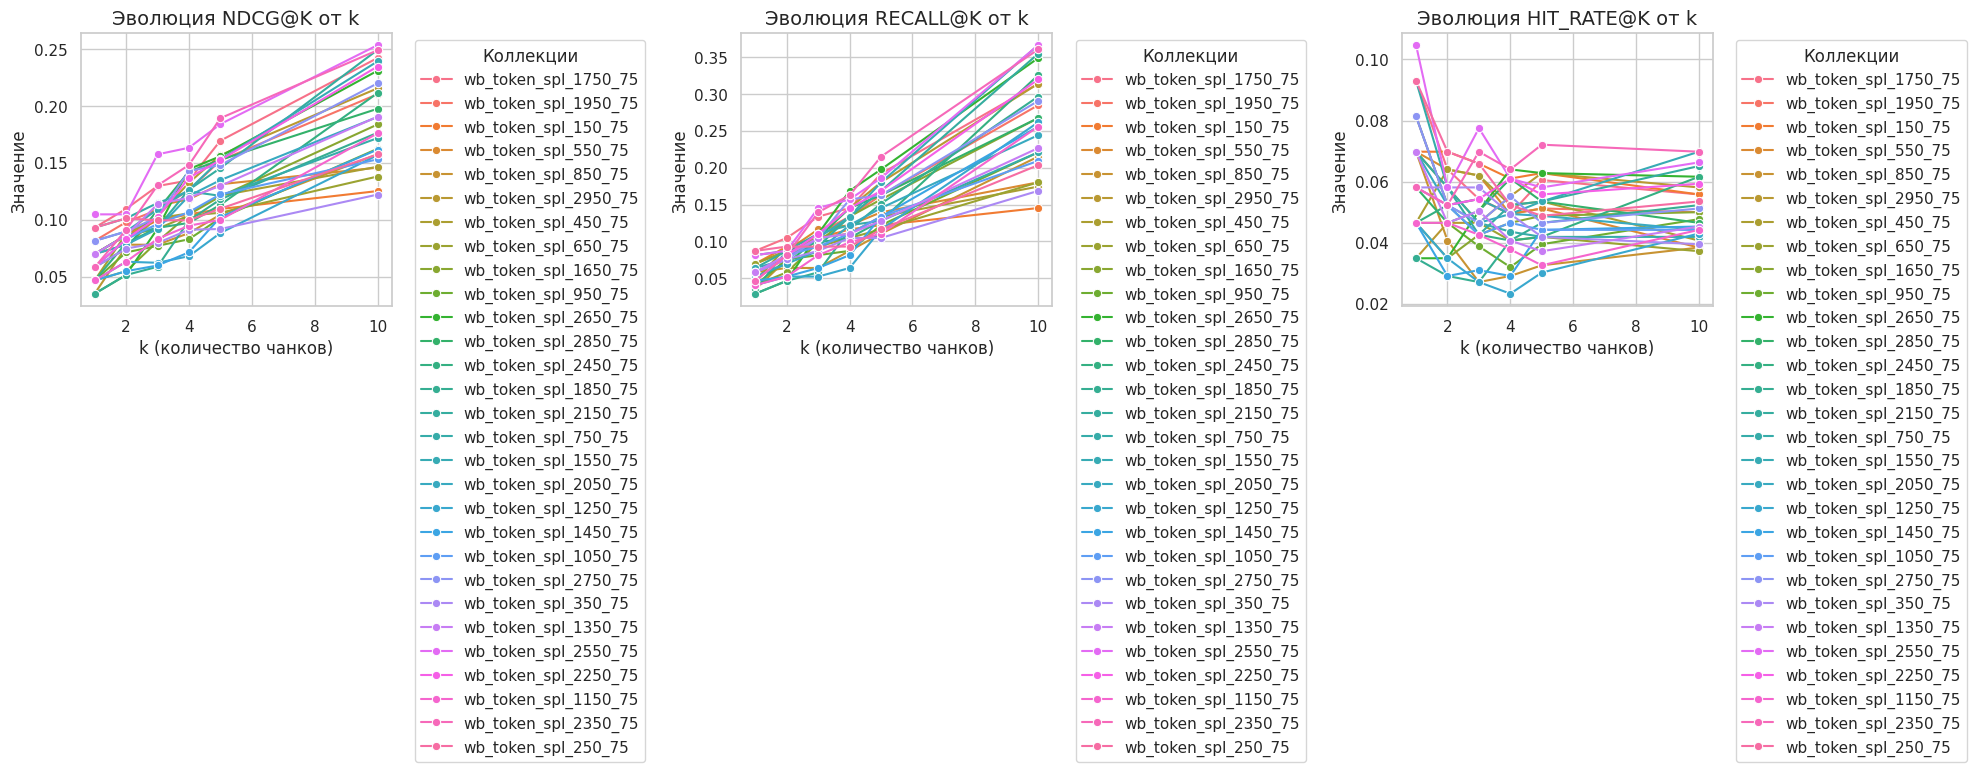

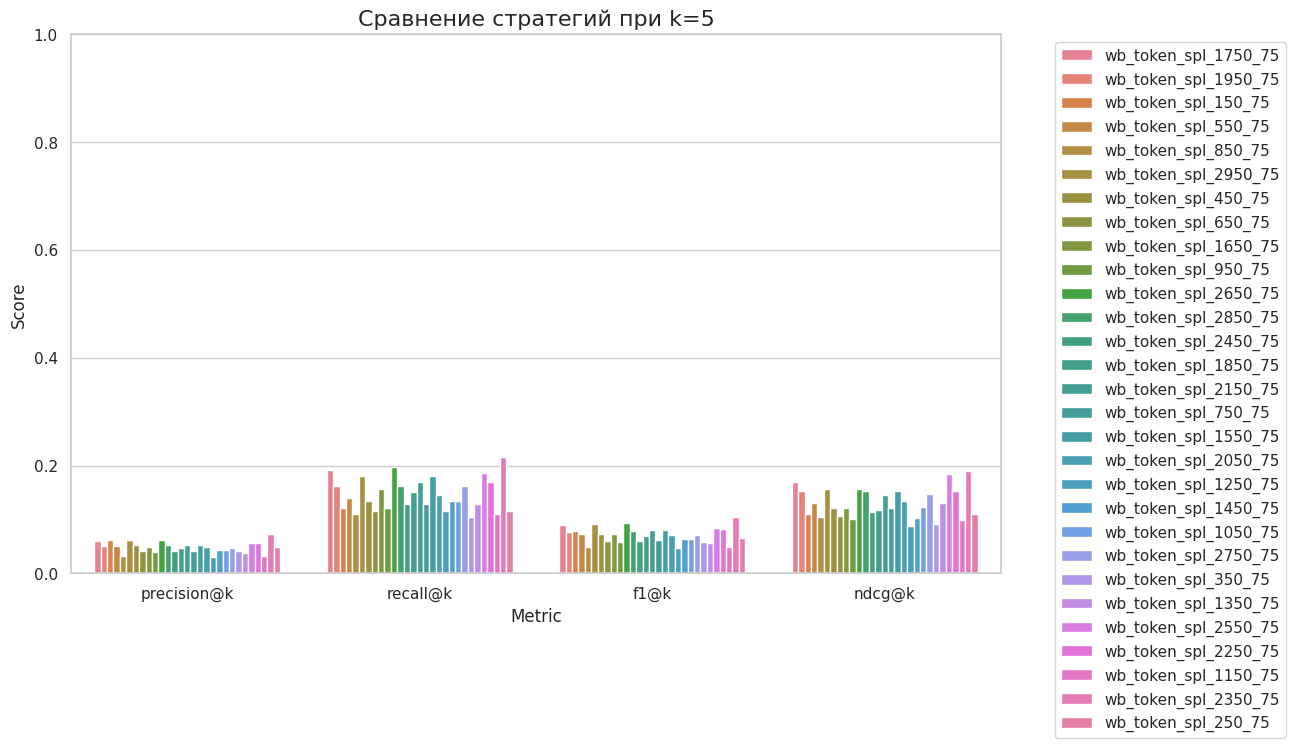

In [116]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Загружаем данные
df = pd.read_csv("results/rag_experiments_results.csv")

# Настройка стиля для "академического" вида
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

def plot_rag_results(df):
    # Список метрик, которые хотим отрисовать
    metrics = ['ndcg@k', 'recall@k', 'hit_rate@k']
    
    fig, axes = plt.subplots(1, len(metrics), figsize=(20, 6))
    
    for i, metric in enumerate(metrics):
        # Строим линейный график: X - это k, Y - значение метрики, цвет - коллекция
        sns.lineplot(
            data=df, 
            x='k', 
            y=metric, 
            hue='collection', 
            marker='o', 
            ax=axes[i]
        )
        axes[i].set_title(f'Эволюция {metric.upper()} от k', fontsize=14)
        axes[i].set_xlabel('k (количество чанков)')
        axes[i].set_ylabel('Значение')
        axes[i].legend(title='Коллекции', bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.savefig("results/metrics_evolution.png", dpi=300)
    plt.show()

# 2. Сравнение всех коллекций при конкретном k (например, k=5)
def plot_comparison_at_k(df, target_k=5):
    df_k = df[df['k'] == target_k].melt(
        id_vars=['collection', 'k'], 
        value_vars=['precision@k', 'recall@k', 'f1@k', 'ndcg@k'],
        var_name='Metric', 
        value_name='Score'
    )
    
    plt.figure(figsize=(12, 7))
    sns.barplot(data=df_k, x='Metric', y='Score', hue='collection')
    plt.title(f'Сравнение стратегий при k={target_k}', fontsize=16)
    plt.ylim(0, 1) # Метрики обычно от 0 до 1
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.savefig(f"results/comparison_at_k_{target_k}.png", dpi=300)
    plt.show()

# Запускаем
plot_rag_results(df)
plot_comparison_at_k(df, target_k=5)

/home/yuri/HSE/ВКР/RAG/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:2054: RuntimeWarning: coroutine 'AsyncQdrantClient.get_collections' was never awaited
  setattr(obj, attr, val)


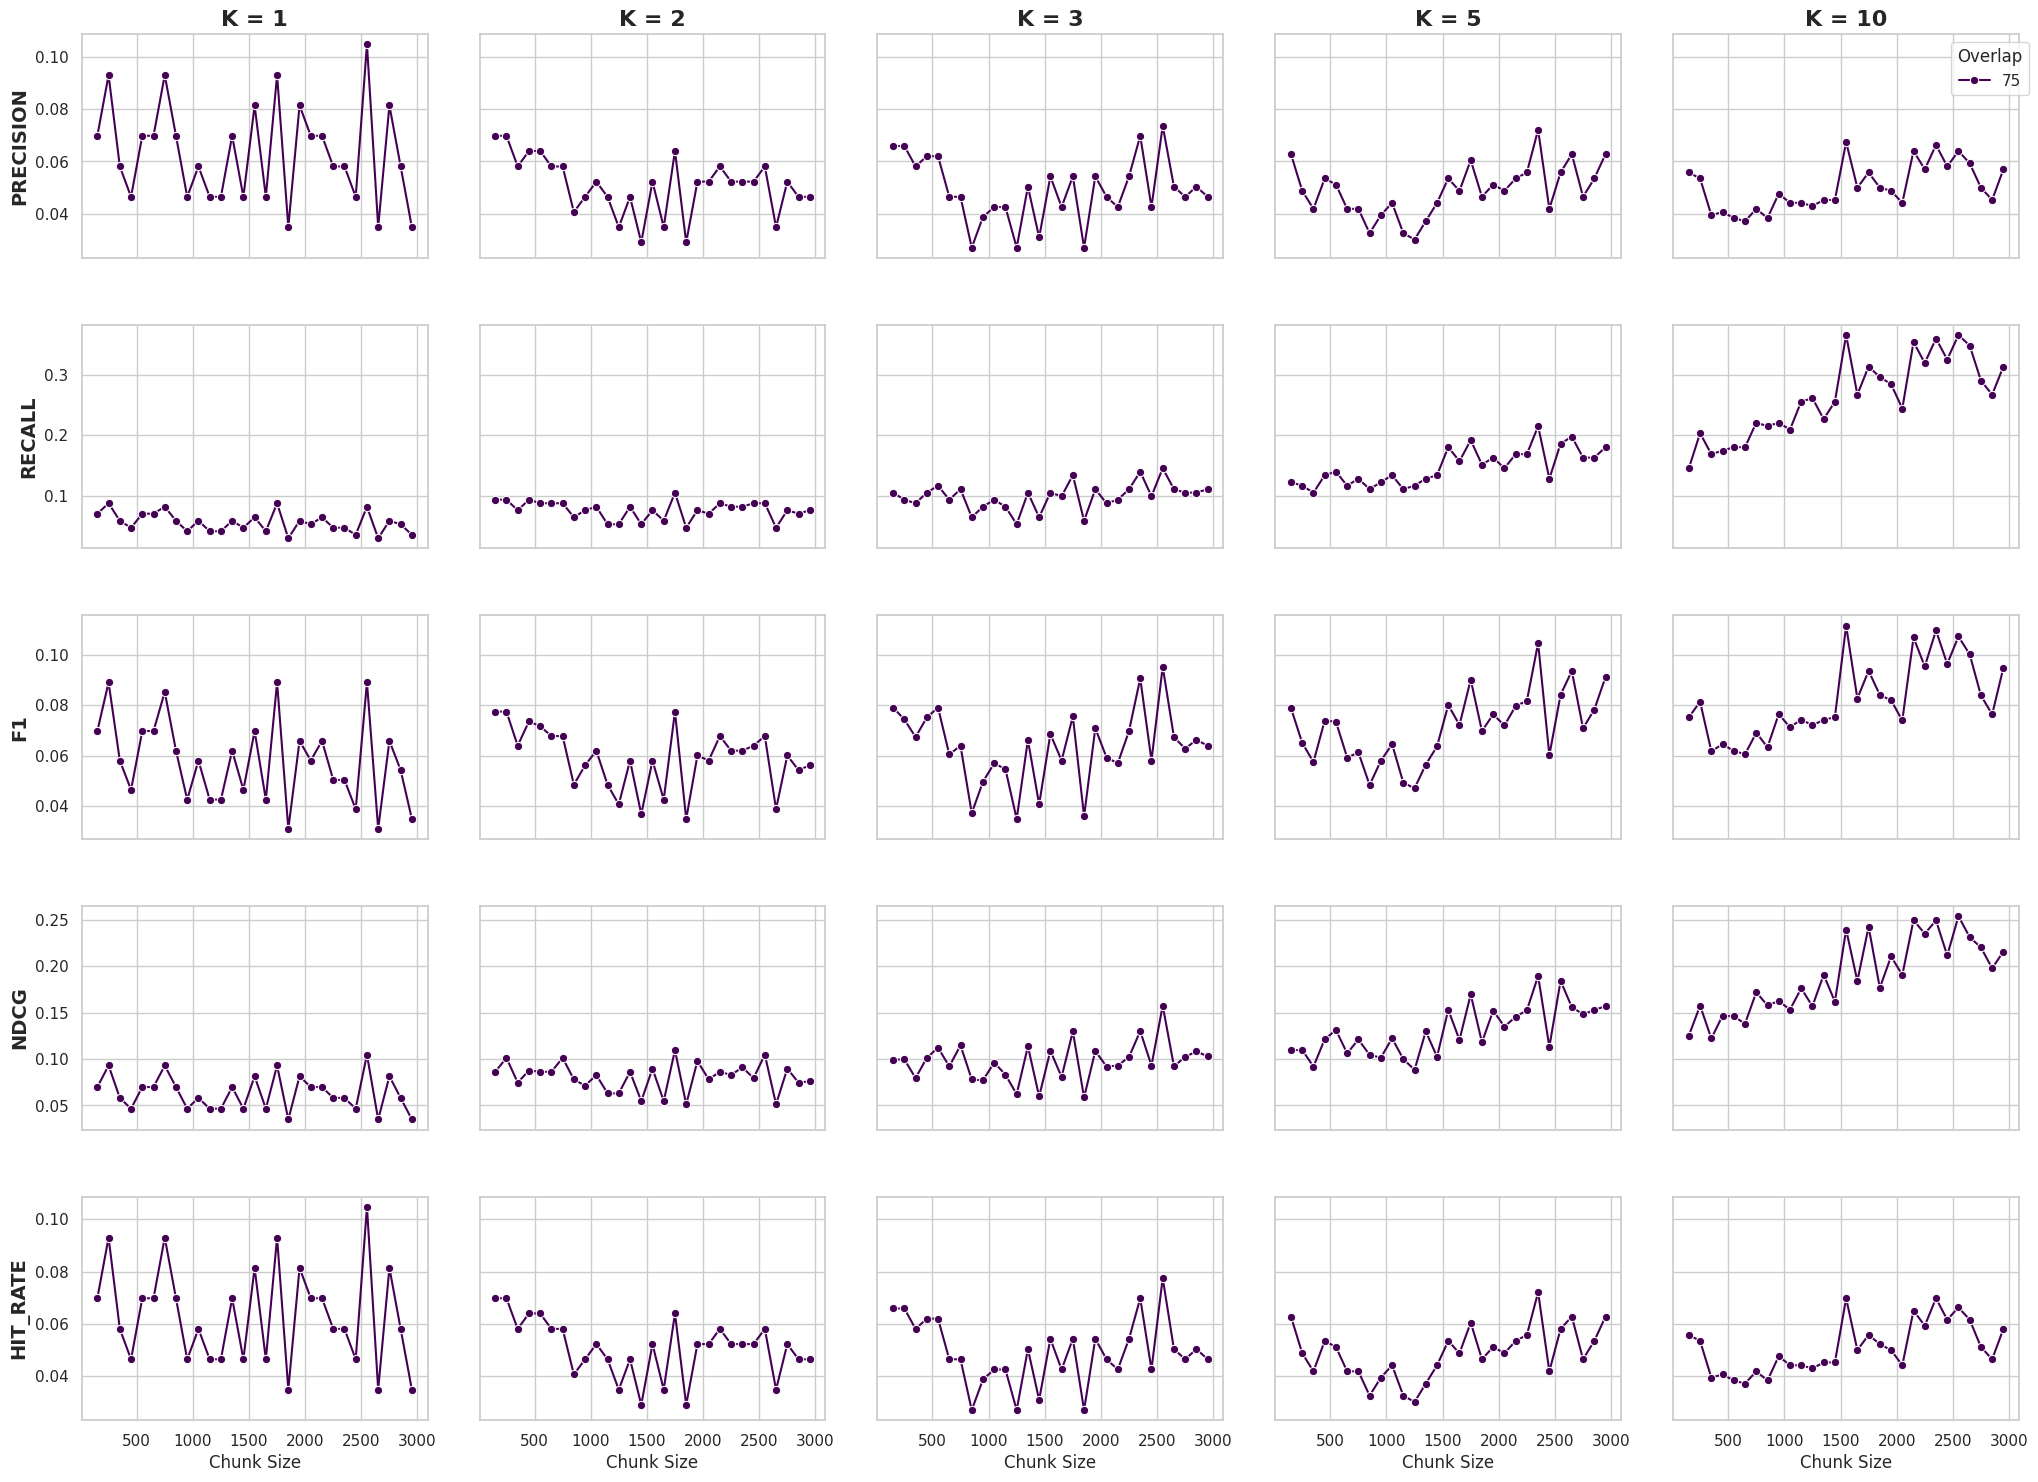

In [118]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re

# 1. Загрузка и предобработка
df = pd.read_csv("results/rag_experiments_results.csv")

def extract_params(row):
    # Ищем числа в формате ..._size_overlap
    match = re.search(r'(\d+)_(\d+)$', row['collection'])
    if match:
        return int(match.group(1)), int(match.group(2))
    return None, None

df['chunk_size'], df['overlap'] = zip(*df.apply(extract_params, axis=1))
df = df.dropna(subset=['chunk_size']).sort_values('chunk_size')

# 2. Настройка параметров сетки
metrics = ['precision@k', 'recall@k', 'f1@k', 'ndcg@k', 'hit_rate@k']
k_values = [1, 2, 3, 5, 10] # 5 колонок, как заказывали

fig, axes = plt.subplots(len(metrics), len(k_values), 
                         figsize=(25, 18), 
                         sharex='col', 
                         sharey='row')

plt.subplots_adjust(hspace=0.3, wspace=0.15)

# 3. Цикл построения
for row_idx, metric in enumerate(metrics):
    for col_idx, k_val in enumerate(k_values):
        ax = axes[row_idx, col_idx]
        
        # Фильтруем данные для конкретного k
        subset = df[df['k'] == k_val]
        
        # Строим график: зависимость метрики от размера чанка
        # hue='overlap' позволит увидеть разные линии, если у вас несколько вариантов перекрытия
        sns.lineplot(
            data=subset, 
            x='chunk_size', 
            y=metric, 
            marker='o', 
            ax=ax,
            hue='overlap',
            palette='viridis'
        )
        
        # Убираем легенду из всех графиков, кроме одного (чтобы не дублировать)
        if row_idx == 0 and col_idx == len(k_values)-1:
            ax.legend(title='Overlap', bbox_to_anchor=(1.05, 1))
        else:
            ax.get_legend().remove() if ax.get_legend() else None

        # Подписи только для краев сетки для чистоты
        if row_idx == 0:
            ax.set_title(f'K = {k_val}', fontsize=16, fontweight='bold')
        if col_idx == 0:
            ax.set_ylabel(metric.replace('@k', '').upper(), fontsize=14, fontweight='bold')
        else:
            ax.set_ylabel('')
            
        ax.set_xlabel('Chunk Size' if row_idx == len(metrics)-1 else '')

# Сохранение
plt.savefig("results/rag_hyperparams_grid.png", dpi=300, bbox_inches='tight')
plt.show()

In [111]:
# Проверка памяти GPU
def check_gpu_memory():
    """Выводит информацию о памяти GPU"""
    if not torch.cuda.is_available():
        print("GPU не доступен")
        return

    allocated = torch.cuda.memory_allocated() / 1024**2
    reserved = torch.cuda.memory_reserved() / 1024**2
    total = torch.cuda.get_device_properties(0).total_memory / 1024**2

    print(f"📊 GPU Memory Status:")
    print(f"   Total: {total:.0f} MB")
    print(f"   Allocated: {allocated:.1f} MB ({allocated/total*100:.1f}%)")
    print(f"   Reserved: {reserved:.1f} MB ({reserved/total*100:.1f}%)")
    print(f"   Free: {total - reserved:.1f} MB")

check_gpu_memory()

📊 GPU Memory Status:
   Total: 15832 MB
   Allocated: 4813.5 MB (30.4%)
   Reserved: 12052.0 MB (76.1%)
   Free: 3779.6 MB


In [112]:
# Очистка памяти перед загрузкой новой модели
def cleanup_memory():
    """Полная очистка памяти GPU"""
    # Удаляем все большие объекты
    for obj in gc.get_objects():
        try:
          if isinstance(obj, torch.Tensor):
              del obj
        except:
          pass

    # Очищаем кэш
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    # Сборщик мусора
    gc.collect()

    torch.cuda.ipc_collect()

    print("✅ Память очищена")
    check_gpu_memory()

cleanup_memory()

/tmp/ipykernel_97636/2524379139.py:7: FutureWarning: `torch.distributed.reduce_op` is deprecated, please use `torch.distributed.ReduceOp` instead
  if isinstance(obj, torch.Tensor):


✅ Память очищена
📊 GPU Memory Status:
   Total: 15832 MB
   Allocated: 4813.5 MB (30.4%)
   Reserved: 4882.0 MB (30.8%)
   Free: 10949.6 MB
